***
**Detector Counts based on LSAs**
***


In [5]:
from pathlib import Path
import xml.etree.ElementTree as ET
import pandas as pd

# ============================================================
# SATURATION COMPARISON - STEP 1
# Parse SUMO E1 detector output and save by LSA + scenario
# ============================================================

# Change this for each simulation run
SCENARIO_NAME = "weekday_evening"

E1_FILE = Path(
    r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\digital_twin\simulation\Corridor_e1_output.xml"
)

OUT_BASE = Path(
    r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_comparison"
)

OUT_BASE.mkdir(parents=True, exist_ok=True)

# ============================================================
# HELPER
# ============================================================

def detect_lsa(detector_id):
    if detector_id.startswith("LSA16"):
        return "LSA16"
    elif detector_id.startswith("LSA10"):
        return "LSA10"
    elif detector_id.startswith("LSA9"):
        return "LSA9"
    elif detector_id.startswith("LSA1"):
        return "LSA1"
    elif detector_id.startswith("LSA8"):
        return "LSA8"
    else:
        return "UNKNOWN"


def extract_real_detector_id(detector_id):
    """
    Example:
    LSA16_E_id10 -> 10
    LSA1_E_id23 -> 23
    LSA9_WE_id4 -> 4
    """
    if "_id" in detector_id:
        return int(detector_id.split("_id")[-1])
    return None


# ============================================================
# READ XML
# ============================================================

tree = ET.parse(E1_FILE)
root = tree.getroot()

rows = []

for interval in root.findall("interval"):
    detector_id = interval.get("id")
    lsa = detect_lsa(detector_id)

    rows.append({
        "scenario": SCENARIO_NAME,
        "lsa": lsa,
        "detector_id_sumo": detector_id,
        "detector_id_real": extract_real_detector_id(detector_id),
        "begin_s": float(interval.get("begin")),
        "end_s": float(interval.get("end")),
        "nVehEntered": float(interval.get("nVehEntered", 0)),
        "nVehContrib": float(interval.get("nVehContrib", 0)),
        "flow": float(interval.get("flow", 0)),
        "occupancy": float(interval.get("occupancy", 0)),
        "speed": float(interval.get("speed", -1)),
        "harmonicMeanSpeed": float(interval.get("harmonicMeanSpeed", -1)),
    })

df = pd.DataFrame(rows)

if df.empty:
    raise ValueError("No E1 detector intervals found.")

# ============================================================
# SAVE FULL OUTPUT
# ============================================================

scenario_out = OUT_BASE / "simulation_outputs" / SCENARIO_NAME
scenario_out.mkdir(parents=True, exist_ok=True)

full_csv = scenario_out / f"{SCENARIO_NAME}_e1_all_detectors.csv"
df.to_csv(full_csv, index=False, encoding="utf-8-sig")

print("Saved full E1 detector table:")
print(full_csv)

# ============================================================
# SAVE BY LSA
# ============================================================

for lsa, temp in df.groupby("lsa"):
    if lsa == "UNKNOWN":
        continue

    out_dir = OUT_BASE / lsa / SCENARIO_NAME
    out_dir.mkdir(parents=True, exist_ok=True)

    out_csv = out_dir / f"{lsa}_{SCENARIO_NAME}_e1_detectors.csv"
    temp.to_csv(out_csv, index=False, encoding="utf-8-sig")

    print("Saved:")
    print(out_csv)

# ============================================================
# BASIC CHECK
# ============================================================

print("\nDetector counts by LSA:")
print(
    df.groupby("lsa")
    .agg(
        n_detectors=("detector_id_sumo", "nunique"),
        total_nVehEntered=("nVehEntered", "sum"),
        mean_occupancy=("occupancy", "mean")
    )
    .reset_index()
)

Saved full E1 detector table:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_comparison\simulation_outputs\weekday_evening\weekday_evening_e1_all_detectors.csv
Saved:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_comparison\LSA1\weekday_evening\LSA1_weekday_evening_e1_detectors.csv
Saved:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_comparison\LSA10\weekday_evening\LSA10_weekday_evening_e1_detectors.csv
Saved:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_comparison\LSA16\weekday_evening\LSA16_weekday_evening_e1_detectors.csv
Saved:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_comparison\LSA9\weekday_evening\LSA9_weekday_evening_e1_detectors.csv

Detector counts by LSA:
     lsa  n_detectors  total_nVehEntered  mean_occupancy
0   LSA1           17             4584.0       30.291294
1  LSA10            8             1429.0       15.860000
2  LSA16           13             3183.0       19.238923
3   LSA9            9             1512.0       30.671111


## Detector, Movement, TLS Index and Signal Group Mapping

### LSA16 — TLS ID: 9873

| Approach | Detector ID | Movement | TLS Index | Signal Group | Note |
|---|---:|---|---|---|---|
| West | 4 | Left turn | 8 | K2 |  |
| West | 3 | Straight | 7 | K2 | Right-turn pocket has no detector |
| West | — | Right turn | 6 | K2 / K7 | No detector |
| South | 33 | Straight | 5 | K1 |  |
| South | 2 | Straight | 4 | K1 |  |
| South | 1 | Right turn | 3 | K1 |  |
| East | 10 | Straight + right | 0, 1 | K4 |  |
| East | 11 | Left turn | 2 | K4 |  |
| North | 6 | Right turn | 9 | K3 |  |
| North | 7 | Straight | 10 | K3 | Check: user text mentioned ID 10, but north straight was previously ID 7 |

---

### LSA10 — TLS ID: 9876

| Approach | Detector ID | Movement | TLS Index | Signal Group | Note |
|---|---:|---|---|---|---|
| West | 1 | Straight + right | 8, 9, 10 | K1 |  |
| South | 31 | Multi-movement | 4, 5, 6, 7 | K5 |  |
| East | 3 | Straight + right | 0, 1, 2 | K4 |  |
| East | 4 | Straight | 3 | K4 |  |
| North-East | 29 | Right turn | 16 | K3 |  |
| North-West | 27 | Left turn | 13, 14, 15 | K2 |  |
| North-West | 26 | Straight + right | 11, 12 | K2 |  |

---

### LSA8

| Approach | Detector ID | Movement | TLS Index | Signal Group | Note |
|---|---:|---|---|---|---|
| — | — | — | — | — | Saturation flow comparison not calculated because required detector/saturation data is not available |

---

### LSA9 — TLS ID: LSA9

| Approach | Detector ID | Movement | TLS Index | Signal Group | Note |
|---|---:|---|---|---|---|
| West | 2 | Straight + left | 15, 16, 17 | K1 |  |
| West | 1 | Straight + right | 13, 14 | K1 |  |
| South | 10 | Multi-movement | 9, 10, 11, 12 | K4 |  |
| East | 8 | Straight + right | 5, 6, 7 | K3 |  |
| East | 9 | Straight | 8 | K3 |  |
| North-West | 4 | Straight + right | 0, 1 | K2 |  |
| North-West | 5 | Movement | 2, 3, 4 | K2 |  |
| North-East | 3 | Multi-movement | 18, 19, 20, 21 | K2 |  |

---

### LSA1 — TLS ID: 9869

| Approach | Detector ID | Movement | TLS Index | Signal Group | Note |
|---|---:|---|---|---|---|
| West | 7 | Left turn | 11 | K1 |  |
| West | 9 | Straight + right | 9, 10 | K2 |  |
| South | 11 | Straight | — | K3 | Faulty detector |
| East | 27 | Right turn | 3 | K6 | User text says west, but this appears to be the opposite/east approach |
| East | 13 | Straight + right | 4 | K4 | User text says west, but likely east approach |
| East | 23 | Straight | 5 | K4 | User text says west, but likely east approach |
| East | 26 | Left turn | 6 | K5 | User text says west, but likely east approach |
| North | 40 | Right turn | 0 | K8 |  |
| North | 28 | Straight | 1 | K7 |  |
| North | 30 | Left turn | 2 | K7 |  |

---

## Notes for Saturation Comparison

- The first 900 seconds of the SUMO simulation are treated as warm-up and are excluded from the comparison.
- The analysis intervals after warm-up are:
  - 900–1800 s → first 15-minute analysis bin
  - 1800–2700 s → second 15-minute analysis bin
  - 2700–3600 s → third 15-minute analysis bin
  - 3600–4500 s → fourth 15-minute analysis bin
- LSA8 is excluded from the saturation comparison because the required detector/saturation information is not available.
- LSA1 can be processed for simulation-side flow/service values, but it should not be directly compared with real saturation results if no reliable real-world saturation reference is available.

In [6]:
from pathlib import Path
import pandas as pd

# ============================================================
# SATURATION COMPARISON - STEP 2
# Combine all scenario E1 outputs after warm-up
# and aggregate by LSA + approach + signal group
# ============================================================

OUT_BASE = Path(
    r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_comparison"
)

SCENARIOS = [
    "weekday_morning",
    "weekday_evening",
    "weekend_morning",
    "weekend_evening",
]

WARMUP_S = 900

# ============================================================
# DETECTOR → APPROACH / SIGNAL GROUP MAPPING
# ============================================================

mapping_rows = [
    # ---------------- LSA16 ----------------
    ("LSA16", 4, "west", "left", "K2"),
    ("LSA16", 3, "west", "straight", "K2"),
    ("LSA16", 33, "south", "straight", "K1"),
    ("LSA16", 2, "south", "straight", "K1"),
    ("LSA16", 1, "south", "right", "K1"),
    ("LSA16", 10, "east", "straight_right", "K4"),
    ("LSA16", 11, "east", "left", "K4"),
    ("LSA16", 6, "north", "right", "K3"),
    ("LSA16", 7, "north", "straight", "K3"),

    # ---------------- LSA10 ----------------
    ("LSA10", 1, "west", "straight_right", "K1"),
    ("LSA10", 31, "south", "multi_movement", "K5"),
    ("LSA10", 3, "east", "straight_right", "K4"),
    ("LSA10", 4, "east", "straight", "K4"),
    ("LSA10", 29, "north_east", "right", "K3"),
    ("LSA10", 27, "north_west", "left", "K2"),
    ("LSA10", 26, "north_west", "straight_right", "K2"),

    # ---------------- LSA9 ----------------
    ("LSA9", 2, "west", "straight_left", "K1"),
    ("LSA9", 1, "west", "straight_right", "K1"),
    ("LSA9", 10, "south", "multi_movement", "K4"),
    ("LSA9", 8, "east", "straight_right", "K3"),
    ("LSA9", 9, "east", "straight", "K3"),
    ("LSA9", 4, "north_west", "straight_right", "K2"),
    ("LSA9", 5, "north_west", "movement", "K2"),
    ("LSA9", 3, "north_east", "multi_movement", "K2"),

    # ---------------- LSA1 ----------------
    # LSA1 is processed, but later not directly compared with real saturation.
    ("LSA1", 7, "west", "left", "K1"),
    ("LSA1", 9, "west", "straight_right", "K2"),
    ("LSA1", 11, "south", "straight_faulty", "K3"),
    ("LSA1", 27, "east", "right", "K6"),
    ("LSA1", 13, "east", "straight_right", "K4"),
    ("LSA1", 23, "east", "straight", "K4"),
    ("LSA1", 26, "east", "left", "K5"),
    ("LSA1", 40, "north", "right", "K8"),
    ("LSA1", 28, "north", "straight", "K7"),
    ("LSA1", 30, "north", "left", "K7"),
]

mapping = pd.DataFrame(
    mapping_rows,
    columns=["lsa", "detector_id_real", "approach", "movement", "signal_group"]
)

# Save mapping for documentation
processed_dir = OUT_BASE / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)

mapping.to_csv(
    processed_dir / "detector_approach_signal_group_mapping.csv",
    index=False,
    encoding="utf-8-sig"
)

# ============================================================
# READ ALL SAVED E1 CSV FILES
# ============================================================

all_rows = []

for scenario in SCENARIOS:
    file_path = (
        OUT_BASE
        / "simulation_outputs"
        / scenario
        / f"{scenario}_e1_all_detectors.csv"
    )

    if not file_path.exists():
        print(f"Missing file, skipped: {file_path}")
        continue

    temp = pd.read_csv(file_path)

    # keep only after warm-up
    temp = temp[temp["begin_s"] >= WARMUP_S].copy()

    # shift analysis time so that 900-1800 becomes 0-900
    temp["analysis_begin_s"] = temp["begin_s"] - WARMUP_S
    temp["analysis_end_s"] = temp["end_s"] - WARMUP_S

    # create 15-min bin labels
    temp["bin_no"] = (temp["analysis_begin_s"] // 900).astype(int) + 1

    temp["bin_label"] = temp["bin_no"].map({
        1: "00-15",
        2: "15-30",
        3: "30-45",
        4: "45-60",
    })

    all_rows.append(temp)

if not all_rows:
    raise ValueError("No scenario E1 CSV files found.")

sim_all = pd.concat(all_rows, ignore_index=True)

# ============================================================
# MERGE WITH DETECTOR MAPPING
# ============================================================

sim_mapped = sim_all.merge(
    mapping,
    on=["lsa", "detector_id_real"],
    how="left"
)

# check unmapped detectors
unmapped = sim_mapped[sim_mapped["approach"].isna()].copy()

if not unmapped.empty:
    print("\nWARNING: Some detectors are not mapped:")
    print(
        unmapped[
            ["scenario", "lsa", "detector_id_sumo", "detector_id_real"]
        ]
        .drop_duplicates()
        .sort_values(["lsa", "detector_id_real"])
    )

# keep only mapped detectors
sim_mapped = sim_mapped[sim_mapped["approach"].notna()].copy()

# ============================================================
# SAVE DETECTOR-LEVEL CLEAN TABLE
# ============================================================

detector_level_csv = processed_dir / "simulation_detector_counts_after_warmup.csv"

sim_mapped.to_csv(
    detector_level_csv,
    index=False,
    encoding="utf-8-sig"
)

print("Saved detector-level simulation table:")
print(detector_level_csv)

# ============================================================
# AGGREGATE BY APPROACH / SIGNAL GROUP / 15-MIN BIN
# ============================================================

approach_counts = (
    sim_mapped
    .groupby(
        [
            "scenario",
            "lsa",
            "approach",
            "signal_group",
            "analysis_begin_s",
            "analysis_end_s",
            "bin_no",
            "bin_label",
        ],
        as_index=False
    )
    .agg(
        sim_count_15min=("nVehEntered", "sum"),
        sim_flow_mean=("flow", "mean"),
        sim_occupancy_mean=("occupancy", "mean"),
        n_detectors_used=("detector_id_real", "nunique"),
    )
)

approach_counts["sim_count_hourly_equivalent"] = (
    approach_counts["sim_count_15min"] * 4
)

approach_csv = processed_dir / "simulation_approach_counts_after_warmup.csv"

approach_counts.to_csv(
    approach_csv,
    index=False,
    encoding="utf-8-sig"
)

print("\nSaved approach-level simulation counts:")
print(approach_csv)

# ============================================================
# BASIC CHECK
# ============================================================

print("\nApproach-level check:")
display(
    approach_counts
    .groupby(["scenario", "lsa", "approach", "signal_group"], as_index=False)
    .agg(
        total_sim_count=("sim_count_15min", "sum"),
        mean_15min_count=("sim_count_15min", "mean"),
        n_bins=("bin_no", "nunique"),
        n_detectors_used=("n_detectors_used", "max"),
    )
    .sort_values(["scenario", "lsa", "approach"])
)


            scenario    lsa detector_id_sumo  detector_id_real
36   weekday_morning   LSA1       LSA1_W_id8                 8
224  weekday_evening   LSA1       LSA1_W_id8                 8
412  weekend_morning   LSA1       LSA1_W_id8                 8
600  weekend_evening   LSA1       LSA1_W_id8                 8
34   weekday_morning   LSA1      LSA1_W_id10                10
222  weekday_evening   LSA1      LSA1_W_id10                10
410  weekend_morning   LSA1      LSA1_W_id10                10
598  weekend_evening   LSA1      LSA1_W_id10                10
33   weekday_morning   LSA1      LSA1_S_id12                12
221  weekday_evening   LSA1      LSA1_S_id12                12
409  weekend_morning   LSA1      LSA1_S_id12                12
597  weekend_evening   LSA1      LSA1_S_id12                12
22   weekday_morning   LSA1      LSA1_E_id14                14
210  weekday_evening   LSA1      LSA1_E_id14                14
398  weekend_morning   LSA1      LSA1_E_id14          

,scenario,lsa,approach,signal_group,total_sim_count,mean_15min_count,n_bins,n_detectors_used
0,weekday_evening,LSA1,east,K4,544.0,136.00,4,2
1,weekday_evening,LSA1,east,K5,151.0,37.75,4,1
2,weekday_evening,LSA1,east,K6,283.0,70.75,4,1
3,weekday_evening,LSA1,north,K7,395.0,98.75,4,2
4,weekday_evening,LSA1,north,K8,188.0,47.00,4,1
...,...,...,...,...,...,...,...,...
79,weekend_morning,LSA16,west,K2,205.0,51.25,4,2
80,weekend_morning,LSA9,east,K3,387.0,96.75,4,2
81,weekend_morning,LSA9,north_west,K2,96.0,24.00,4,2
82,weekend_morning,LSA9,south,K4,4.0,1.00,4,1


In [8]:
from pathlib import Path
import xml.etree.ElementTree as ET
import pandas as pd

# ============================================================
# SATURATION COMPARISON - STEP 3
# Extract green time and cycle time from SUMO TLS files
# Weekday files: morning/evening
# Weekend files: weekend_morning/weekend_evening
# ============================================================

SIM_DIR = Path(
    r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\digital_twin\simulation"
)

OUT_BASE = Path(
    r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_comparison"
)

processed_dir = OUT_BASE / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)

SCENARIOS = [
    "weekday_morning",
    "weekday_evening",
    "weekend_morning",
    "weekend_evening",
]


def scenario_to_file_suffix(scenario):
    if scenario == "weekday_morning":
        return "morning"
    elif scenario == "weekday_evening":
        return "evening"
    elif scenario == "weekend_morning":
        return "weekend_morning"
    elif scenario == "weekend_evening":
        return "weekend_evening"
    else:
        raise ValueError(f"Unknown scenario: {scenario}")


tls_file_map = {
    "LSA16": "tls_9873_{suffix}.xml",
    "LSA10": "tls_9876_{suffix}.xml",
    "LSA9": "tls_LSA9_{suffix}.xml",
    "LSA1": "tls_9869_{suffix}.xml",
}


sg_index_rows = [
    # LSA16
    ("LSA16", "K1", [3, 4, 5]),
    ("LSA16", "K2", [7, 8]),
    ("LSA16", "K3", [9, 10]),
    ("LSA16", "K4", [0, 1, 2]),

    # LSA10
    ("LSA10", "K1", [8, 9, 10]),
    ("LSA10", "K2", [11, 12, 13, 14, 15]),
    ("LSA10", "K3", [16]),
    ("LSA10", "K4", [0, 1, 2, 3]),
    ("LSA10", "K5", [4, 5, 6, 7]),

    # LSA9
    ("LSA9", "K1", [13, 14, 15, 16, 17]),
    ("LSA9", "K2", [0, 1, 2, 3, 4, 18, 19, 20, 21]),
    ("LSA9", "K3", [5, 6, 7, 8]),
    ("LSA9", "K4", [9, 10, 11, 12]),

    # LSA1
    ("LSA1", "K1", [11]),
    ("LSA1", "K2", [9, 10]),
    ("LSA1", "K3", []),
    ("LSA1", "K4", [4, 5]),
    ("LSA1", "K5", [6]),
    ("LSA1", "K6", [3]),
    ("LSA1", "K7", [1, 2]),
    ("LSA1", "K8", [0]),
]

sg_index_map = pd.DataFrame(
    sg_index_rows,
    columns=["lsa", "signal_group", "tls_indices"]
)


def parse_tls_phases(tls_file):
    tree = ET.parse(tls_file)
    root = tree.getroot()

    phases = []

    for phase in root.findall(".//phase"):
        phases.append({
            "duration": float(phase.get("duration")),
            "state": phase.get("state"),
        })

    if not phases:
        raise ValueError(f"No phases found in: {tls_file}")

    return phases


def green_time_for_indices(phases, tls_indices, count_minor_green=True):
    if not tls_indices:
        return 0.0

    green_chars = ["G", "g"] if count_minor_green else ["G"]
    green_time = 0.0

    for phase in phases:
        state = phase["state"]
        duration = phase["duration"]

        for idx in tls_indices:
            if idx < len(state) and state[idx] in green_chars:
                green_time += duration
                break

    return green_time


rows = []

for scenario in SCENARIOS:
    suffix = scenario_to_file_suffix(scenario)

    for lsa, pattern in tls_file_map.items():
        tls_file = SIM_DIR / pattern.format(suffix=suffix)

        if not tls_file.exists():
            print(f"Missing TLS file, skipped: {tls_file}")
            continue

        phases = parse_tls_phases(tls_file)
        cycle_time = sum(p["duration"] for p in phases)

        for _, row in sg_index_map[sg_index_map["lsa"] == lsa].iterrows():
            green_time = green_time_for_indices(
                phases=phases,
                tls_indices=row["tls_indices"],
                count_minor_green=True,
            )

            rows.append({
                "scenario": scenario,
                "file_suffix": suffix,
                "lsa": lsa,
                "signal_group": row["signal_group"],
                "tls_indices": ",".join(map(str, row["tls_indices"])),
                "cycle_time_s": cycle_time,
                "green_time_s": green_time,
                "green_share": green_time / cycle_time if cycle_time > 0 else None,
                "tls_file_used": str(tls_file),
            })

green_df = pd.DataFrame(rows)

green_csv = processed_dir / "sumo_tls_green_times_by_signal_group.csv"

green_df.to_csv(
    green_csv,
    index=False,
    encoding="utf-8-sig"
)

print("Saved green time table:")
print(green_csv)

display(
    green_df.sort_values(["scenario", "lsa", "signal_group"])
)

Saved green time table:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_comparison\processed\sumo_tls_green_times_by_signal_group.csv


,scenario,file_suffix,lsa,signal_group,tls_indices,cycle_time_s,green_time_s,green_share,tls_file_used
34,weekday_evening,evening,LSA1,K1,11,83.0,11.0,0.132530,C:\Users\mogul\OneDrive\Masaüstü\mt_emre\digit...
35,weekday_evening,evening,LSA1,K2,"9,10",83.0,36.0,0.433735,C:\Users\mogul\OneDrive\Masaüstü\mt_emre\digit...
36,weekday_evening,evening,LSA1,K3,,83.0,0.0,0.000000,C:\Users\mogul\OneDrive\Masaüstü\mt_emre\digit...
37,weekday_evening,evening,LSA1,K4,"4,5",83.0,36.0,0.433735,C:\Users\mogul\OneDrive\Masaüstü\mt_emre\digit...
38,weekday_evening,evening,LSA1,K5,6,83.0,11.0,0.132530,C:\Users\mogul\OneDrive\Masaüstü\mt_emre\digit...
...,...,...,...,...,...,...,...,...,...
45,weekend_morning,weekend_morning,LSA16,K4,"0,1,2",86.0,41.0,0.476744,C:\Users\mogul\OneDrive\Masaüstü\mt_emre\digit...
51,weekend_morning,weekend_morning,LSA9,K1,"13,14,15,16,17",175.0,92.0,0.525714,C:\Users\mogul\OneDrive\Masaüstü\mt_emre\digit...
52,weekend_morning,weekend_morning,LSA9,K2,"0,1,2,3,4,18,19,20,21",175.0,45.0,0.257143,C:\Users\mogul\OneDrive\Masaüstü\mt_emre\digit...
53,weekend_morning,weekend_morning,LSA9,K3,"5,6,7,8",175.0,100.0,0.571429,C:\Users\mogul\OneDrive\Masaüstü\mt_emre\digit...


**Simulation Aprroach Counts + Green Times for v/c saturation ratio**

In [9]:
from pathlib import Path
import pandas as pd
import numpy as np

# ============================================================
# SATURATION COMPARISON - STEP 4
# Merge simulation counts with SUMO green times
# and calculate saturation / v-c ratio
# ============================================================

OUT_BASE = Path(
    r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_comparison"
)

processed_dir = OUT_BASE / "processed"

SIM_COUNTS_FILE = processed_dir / "simulation_approach_counts_after_warmup.csv"
GREEN_FILE = processed_dir / "sumo_tls_green_times_by_signal_group.csv"

out_file = processed_dir / "simulation_saturation_by_approach.csv"

# Saturation flow assumption from supervisor
SATURATION_FLOW_VPH = 1800

sim_counts = pd.read_csv(SIM_COUNTS_FILE)
green_df = pd.read_csv(GREEN_FILE)

# ============================================================
# MERGE
# ============================================================

df = sim_counts.merge(
    green_df[
        [
            "scenario",
            "lsa",
            "signal_group",
            "cycle_time_s",
            "green_time_s",
            "green_share",
        ]
    ],
    on=["scenario", "lsa", "signal_group"],
    how="left"
)

# ============================================================
# CALCULATIONS
# ============================================================

# 15-min count converted to hourly demand
df["demand_vph"] = df["sim_count_15min"] * 4

# capacity based on green share
df["capacity_vph"] = SATURATION_FLOW_VPH * df["green_share"]

# volume-to-capacity ratio
df["v_c_ratio"] = df["demand_vph"] / df["capacity_vph"]

# avoid infinite values
df["v_c_ratio"] = df["v_c_ratio"].replace([np.inf, -np.inf], np.nan)

# simple interpretation
df["status"] = np.select(
    [
        df["v_c_ratio"] < 0.85,
        (df["v_c_ratio"] >= 0.85) & (df["v_c_ratio"] <= 1.00),
        df["v_c_ratio"] > 1.00,
    ],
    [
        "below capacity",
        "near capacity",
        "over capacity",
    ],
    default="not calculated"
)

# LSA1 note
df["comparison_note"] = np.where(
    df["lsa"].isin(["LSA1", "LSA8"]),
    "simulation-side only; no direct real saturation comparison",
    "usable for simulation saturation comparison"
)

# ============================================================
# SAVE
# ============================================================

df.to_csv(out_file, index=False, encoding="utf-8-sig")

print("Saved simulation saturation table:")
print(out_file)

display(
    df.sort_values(
        ["scenario", "lsa", "approach", "bin_no"]
    )
)

Saved simulation saturation table:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_comparison\processed\simulation_saturation_by_approach.csv


,scenario,lsa,approach,signal_group,analysis_begin_s,analysis_end_s,bin_no,bin_label,sim_count_15min,sim_flow_mean,...,n_detectors_used,sim_count_hourly_equivalent,cycle_time_s,green_time_s,green_share,demand_vph,capacity_vph,v_c_ratio,status,comparison_note
0,weekday_evening,LSA1,east,K4,0.0,900.0,1,00-15,137.0,276.0,...,2,548.0,83.0,36.0,0.433735,548.0,780.722892,0.701914,below capacity,simulation-side only; no direct real saturatio...
4,weekday_evening,LSA1,east,K5,0.0,900.0,1,00-15,40.0,164.0,...,1,160.0,83.0,11.0,0.132530,160.0,238.554217,0.670707,below capacity,simulation-side only; no direct real saturatio...
8,weekday_evening,LSA1,east,K6,0.0,900.0,1,00-15,68.0,272.0,...,1,272.0,83.0,54.0,0.650602,272.0,1171.084337,0.232263,below capacity,simulation-side only; no direct real saturatio...
1,weekday_evening,LSA1,east,K4,900.0,1800.0,2,15-30,143.0,282.0,...,2,572.0,83.0,36.0,0.433735,572.0,780.722892,0.732654,below capacity,simulation-side only; no direct real saturatio...
5,weekday_evening,LSA1,east,K5,900.0,1800.0,2,15-30,37.0,148.0,...,1,148.0,83.0,11.0,0.132530,148.0,238.554217,0.620404,below capacity,simulation-side only; no direct real saturatio...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
331,weekend_morning,LSA9,south,K4,2700.0,3600.0,4,45-60,0.0,0.0,...,1,0.0,175.0,0.0,0.000000,0.0,0.000000,NaN,not calculated,usable for simulation saturation comparison
332,weekend_morning,LSA9,west,K1,0.0,900.0,1,00-15,119.0,234.0,...,2,476.0,175.0,92.0,0.525714,476.0,946.285714,0.503019,below capacity,usable for simulation saturation comparison
333,weekend_morning,LSA9,west,K1,900.0,1800.0,2,15-30,109.0,214.0,...,2,436.0,175.0,92.0,0.525714,436.0,946.285714,0.460749,below capacity,usable for simulation saturation comparison
334,weekend_morning,LSA9,west,K1,1800.0,2700.0,3,30-45,107.0,212.0,...,2,428.0,175.0,92.0,0.525714,428.0,946.285714,0.452295,below capacity,usable for simulation saturation comparison


In [10]:
from pathlib import Path
import pandas as pd
import numpy as np

# ============================================================
# SATURATION COMPARISON - STEP 5
# Summarize saturation results by scenario + LSA + approach
# ============================================================

OUT_BASE = Path(
    r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_comparison"
)

processed_dir = OUT_BASE / "processed"

IN_FILE = processed_dir / "simulation_saturation_by_approach.csv"
OUT_FILE = processed_dir / "simulation_saturation_summary_by_approach.csv"

df = pd.read_csv(IN_FILE)

summary = (
    df
    .groupby(
        ["scenario", "lsa", "approach", "signal_group"],
        as_index=False
    )
    .agg(
        total_sim_count_1h=("sim_count_15min", "sum"),
        mean_15min_count=("sim_count_15min", "mean"),
        max_15min_count=("sim_count_15min", "max"),
        mean_demand_vph=("demand_vph", "mean"),
        max_demand_vph=("demand_vph", "max"),
        cycle_time_s=("cycle_time_s", "first"),
        green_time_s=("green_time_s", "first"),
        green_share=("green_share", "first"),
        capacity_vph=("capacity_vph", "first"),
        mean_v_c_ratio=("v_c_ratio", "mean"),
        max_v_c_ratio=("v_c_ratio", "max"),
        n_bins=("bin_no", "nunique"),
        n_detectors_used=("n_detectors_used", "max"),
    )
)

summary["mean_status"] = np.select(
    [
        summary["mean_v_c_ratio"] < 0.85,
        (summary["mean_v_c_ratio"] >= 0.85) & (summary["mean_v_c_ratio"] <= 1.00),
        summary["mean_v_c_ratio"] > 1.00,
    ],
    [
        "below capacity",
        "near capacity",
        "over capacity",
    ],
    default="not calculated"
)

summary["max_status"] = np.select(
    [
        summary["max_v_c_ratio"] < 0.85,
        (summary["max_v_c_ratio"] >= 0.85) & (summary["max_v_c_ratio"] <= 1.00),
        summary["max_v_c_ratio"] > 1.00,
    ],
    [
        "below capacity",
        "near capacity",
        "over capacity",
    ],
    default="not calculated"
)

summary["comparison_note"] = np.where(
    summary["lsa"].isin(["LSA1", "LSA8"]),
    "simulation-side only; no direct real saturation comparison",
    "usable for simulation saturation comparison"
)

summary.to_csv(OUT_FILE, index=False, encoding="utf-8-sig")

print("Saved summary table:")
print(OUT_FILE)

display(
    summary.sort_values(["scenario", "lsa", "approach"])
)

Saved summary table:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_comparison\processed\simulation_saturation_summary_by_approach.csv


,scenario,lsa,approach,signal_group,total_sim_count_1h,mean_15min_count,max_15min_count,mean_demand_vph,max_demand_vph,cycle_time_s,green_time_s,green_share,capacity_vph,mean_v_c_ratio,max_v_c_ratio,n_bins,n_detectors_used,mean_status,max_status,comparison_note
0,weekday_evening,LSA1,east,K4,544.0,136.00,143.0,544.0,572.0,83.0,36.0,0.433735,780.722892,0.696790,0.732654,4,2,below capacity,below capacity,simulation-side only; no direct real saturatio...
1,weekday_evening,LSA1,east,K5,151.0,37.75,40.0,151.0,160.0,83.0,11.0,0.132530,238.554217,0.632980,0.670707,4,1,below capacity,below capacity,simulation-side only; no direct real saturatio...
2,weekday_evening,LSA1,east,K6,283.0,70.75,74.0,283.0,296.0,83.0,54.0,0.650602,1171.084337,0.241656,0.252757,4,1,below capacity,below capacity,simulation-side only; no direct real saturatio...
3,weekday_evening,LSA1,north,K7,395.0,98.75,103.0,395.0,412.0,83.0,18.0,0.216867,390.361446,1.011883,1.055432,4,2,over capacity,over capacity,simulation-side only; no direct real saturatio...
4,weekday_evening,LSA1,north,K8,188.0,47.00,56.0,188.0,224.0,83.0,29.0,0.349398,628.915663,0.298927,0.356169,4,1,below capacity,below capacity,simulation-side only; no direct real saturatio...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,weekend_morning,LSA16,west,K2,205.0,51.25,56.0,205.0,224.0,86.0,25.0,0.290698,523.255814,0.391778,0.428089,4,2,below capacity,below capacity,usable for simulation saturation comparison
80,weekend_morning,LSA9,east,K3,387.0,96.75,103.0,387.0,412.0,175.0,100.0,0.571429,1028.571429,0.376250,0.400556,4,2,below capacity,below capacity,usable for simulation saturation comparison
81,weekend_morning,LSA9,north_west,K2,96.0,24.00,30.0,96.0,120.0,175.0,45.0,0.257143,462.857143,0.207407,0.259259,4,2,below capacity,below capacity,usable for simulation saturation comparison
82,weekend_morning,LSA9,south,K4,4.0,1.00,3.0,4.0,12.0,175.0,0.0,0.000000,0.000000,NaN,NaN,4,1,not calculated,not calculated,usable for simulation saturation comparison


In [11]:
from pathlib import Path
import pandas as pd

# ============================================================
# SATURATION COMPARISON - STEP 6
# Export all saturation results to one Excel workbook
# ============================================================

OUT_BASE = Path(
    r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_comparison"
)

processed_dir = OUT_BASE / "processed"

files = {
    "detector_mapping": processed_dir / "detector_approach_signal_group_mapping.csv",
    "green_times": processed_dir / "sumo_tls_green_times_by_signal_group.csv",
    "detector_counts": processed_dir / "simulation_detector_counts_after_warmup.csv",
    "approach_counts": processed_dir / "simulation_approach_counts_after_warmup.csv",
    "saturation_15min": processed_dir / "simulation_saturation_by_approach.csv",
    "summary_by_approach": processed_dir / "simulation_saturation_summary_by_approach.csv",
}

out_xlsx = processed_dir / "simulation_saturation_comparison_results.xlsx"

with pd.ExcelWriter(out_xlsx, engine="openpyxl") as writer:
    for sheet_name, file_path in files.items():
        if file_path.exists():
            temp = pd.read_csv(file_path)
            temp.to_excel(writer, sheet_name=sheet_name[:31], index=False)
        else:
            print(f"Missing, skipped: {file_path}")

print("Saved Excel workbook:")
print(out_xlsx)

Saved Excel workbook:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_comparison\processed\simulation_saturation_comparison_results.xlsx


In [12]:
from pathlib import Path
import pandas as pd
import numpy as np

# ============================================================
# SATURATION COMPARISON - STEP 7
# Compare simulation saturation results across scenarios
# ============================================================

OUT_BASE = Path(
    r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_comparison"
)

processed_dir = OUT_BASE / "processed"

IN_FILE = processed_dir / "simulation_saturation_summary_by_approach.csv"
OUT_XLSX = processed_dir / "simulation_saturation_comparison_tables.xlsx"

df = pd.read_csv(IN_FILE)

# ============================================================
# 1) Keep main comparison columns
# ============================================================

comparison = df[
    [
        "scenario",
        "lsa",
        "approach",
        "signal_group",
        "total_sim_count_1h",
        "mean_demand_vph",
        "max_demand_vph",
        "cycle_time_s",
        "green_time_s",
        "green_share",
        "capacity_vph",
        "mean_v_c_ratio",
        "max_v_c_ratio",
        "mean_status",
        "max_status",
        "comparison_note",
    ]
].copy()

# round for readability
round_cols = [
    "mean_demand_vph",
    "max_demand_vph",
    "green_share",
    "capacity_vph",
    "mean_v_c_ratio",
    "max_v_c_ratio",
]

for col in round_cols:
    comparison[col] = comparison[col].round(3)

# ============================================================
# 2) Wide table: mean v/c ratio by scenario
# ============================================================

vc_wide = comparison.pivot_table(
    index=["lsa", "approach", "signal_group"],
    columns="scenario",
    values="mean_v_c_ratio",
    aggfunc="first"
).reset_index()

vc_wide.columns.name = None

# ============================================================
# 3) Wide table: max v/c ratio by scenario
# ============================================================

max_vc_wide = comparison.pivot_table(
    index=["lsa", "approach", "signal_group"],
    columns="scenario",
    values="max_v_c_ratio",
    aggfunc="first"
).reset_index()

max_vc_wide.columns.name = None

# ============================================================
# 4) Critical approaches
# ============================================================

critical = comparison[
    comparison["max_v_c_ratio"] >= 0.85
].copy()

critical = critical.sort_values(
    ["max_v_c_ratio", "mean_v_c_ratio"],
    ascending=False
)

# ============================================================
# 5) Ranking by scenario
# ============================================================

ranking = comparison.copy()

ranking["rank_in_scenario"] = (
    ranking
    .groupby("scenario")["max_v_c_ratio"]
    .rank(method="dense", ascending=False)
)

ranking = ranking.sort_values(
    ["scenario", "rank_in_scenario"]
)

# ============================================================
# 6) LSA-level summary
# ============================================================

lsa_summary = (
    comparison
    .groupby(["scenario", "lsa"], as_index=False)
    .agg(
        total_sim_count_1h=("total_sim_count_1h", "sum"),
        mean_v_c_ratio=("mean_v_c_ratio", "mean"),
        max_v_c_ratio=("max_v_c_ratio", "max"),
        n_approaches=("approach", "nunique"),
    )
)

lsa_summary["overall_status"] = np.select(
    [
        lsa_summary["max_v_c_ratio"] < 0.85,
        (lsa_summary["max_v_c_ratio"] >= 0.85) & (lsa_summary["max_v_c_ratio"] <= 1.00),
        lsa_summary["max_v_c_ratio"] > 1.00,
    ],
    [
        "below capacity",
        "near capacity",
        "over capacity",
    ],
    default="not calculated"
)

# ============================================================
# 7) Save Excel
# ============================================================

with pd.ExcelWriter(OUT_XLSX, engine="openpyxl") as writer:
    comparison.to_excel(writer, sheet_name="full_comparison", index=False)
    vc_wide.to_excel(writer, sheet_name="mean_vc_wide", index=False)
    max_vc_wide.to_excel(writer, sheet_name="max_vc_wide", index=False)
    critical.to_excel(writer, sheet_name="critical_approaches", index=False)
    ranking.to_excel(writer, sheet_name="ranking_by_scenario", index=False)
    lsa_summary.to_excel(writer, sheet_name="lsa_summary", index=False)

print("Saved comparison workbook:")
print(OUT_XLSX)

print("\nMost critical approaches:")
display(
    critical[
        [
            "scenario",
            "lsa",
            "approach",
            "signal_group",
            "total_sim_count_1h",
            "green_time_s",
            "capacity_vph",
            "mean_v_c_ratio",
            "max_v_c_ratio",
            "max_status",
        ]
    ].head(20)
)

print("\nLSA-level summary:")
display(lsa_summary.sort_values(["scenario", "max_v_c_ratio"], ascending=[True, False]))

Saved comparison workbook:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_comparison\processed\simulation_saturation_comparison_tables.xlsx

Most critical approaches:


,scenario,lsa,approach,signal_group,total_sim_count_1h,green_time_s,capacity_vph,mean_v_c_ratio,max_v_c_ratio,max_status
38,weekday_morning,LSA9,east,K3,541.0,25.0,416.667,1.298,1.382,over capacity
3,weekday_evening,LSA1,north,K7,395.0,18.0,390.361,1.012,1.055,over capacity
17,weekday_evening,LSA9,east,K3,505.0,40.0,525.547,0.961,1.035,over capacity
27,weekday_morning,LSA1,west,K1,178.0,9.0,197.561,0.901,1.012,over capacity
41,weekday_morning,LSA9,west,K1,588.0,42.0,700.000,0.840,1.000,near capacity
48,weekend_evening,LSA1,west,K1,168.0,9.0,197.561,0.850,0.952,near capacity
15,weekday_evening,LSA16,south,K1,306.0,22.0,460.465,0.665,0.903,near capacity
36,weekday_morning,LSA16,south,K1,379.0,23.0,475.862,0.796,0.899,near capacity
69,weekend_morning,LSA1,west,K1,92.0,5.0,109.756,0.838,0.875,near capacity
20,weekday_evening,LSA9,west,K1,377.0,40.0,525.547,0.717,0.852,near capacity



LSA-level summary:


,scenario,lsa,total_sim_count_1h,mean_v_c_ratio,max_v_c_ratio,n_approaches,overall_status
0,weekday_evening,LSA1,1967.0,0.536857,1.055,4,over capacity
3,weekday_evening,LSA9,1086.0,0.585250,1.035,4,over capacity
2,weekday_evening,LSA16,1365.0,0.553250,0.903,4,near capacity
1,weekday_evening,LSA10,1057.0,0.397000,0.704,5,below capacity
7,weekday_morning,LSA9,1234.0,0.649500,1.382,4,over capacity
4,weekday_morning,LSA1,1847.0,0.551143,1.012,4,over capacity
6,weekday_morning,LSA16,1275.0,0.528000,0.899,4,near capacity
5,weekday_morning,LSA10,1008.0,0.354800,0.677,5,below capacity
8,weekend_evening,LSA1,1582.0,0.469143,0.952,4,near capacity
11,weekend_evening,LSA9,1240.0,0.435750,0.751,4,below capacity


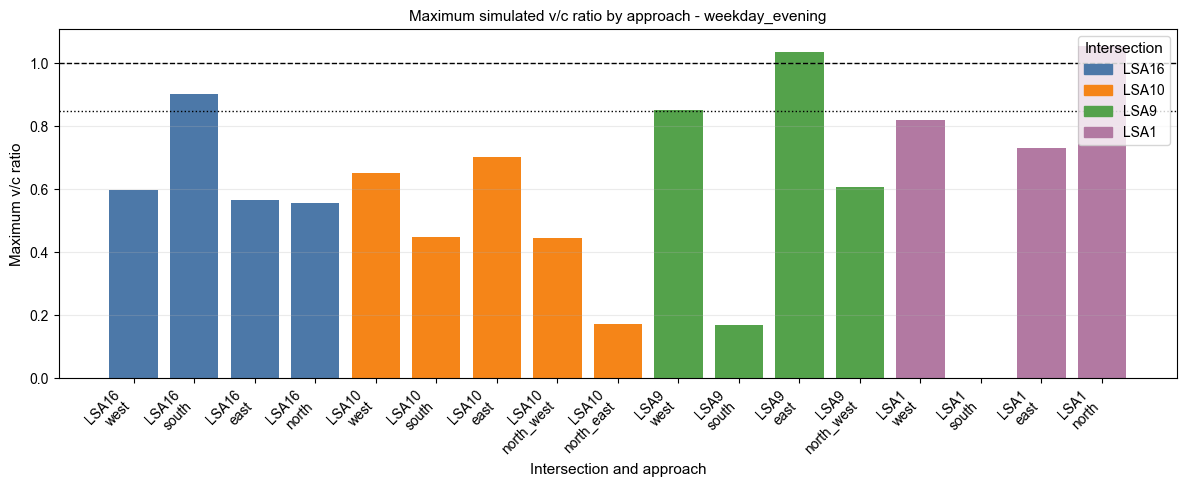

Saved: C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_comparison\figures\max_vc_ratio_weekday_evening_grouped_by_lsa.png


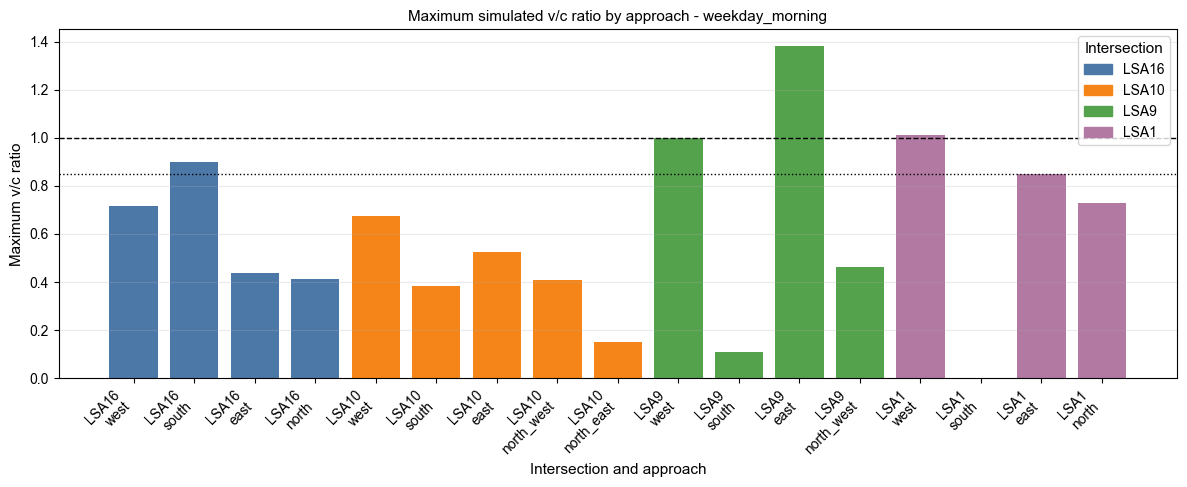

Saved: C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_comparison\figures\max_vc_ratio_weekday_morning_grouped_by_lsa.png


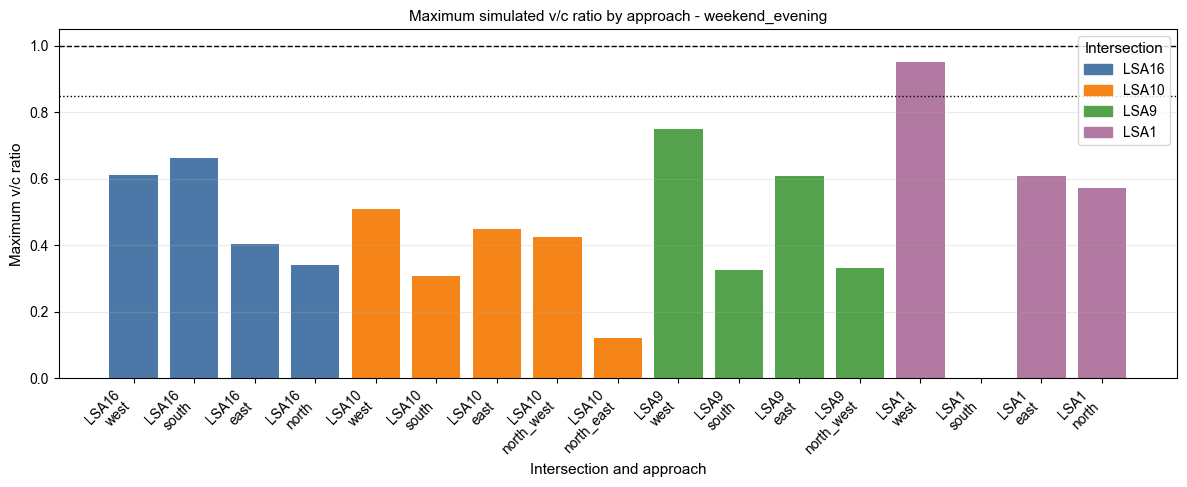

Saved: C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_comparison\figures\max_vc_ratio_weekend_evening_grouped_by_lsa.png


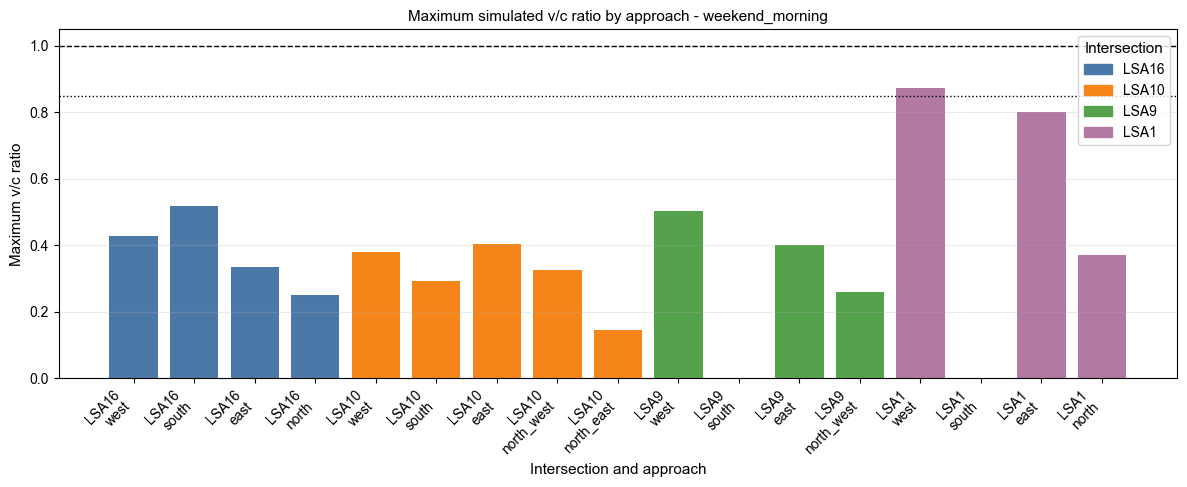

Saved: C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_comparison\figures\max_vc_ratio_weekend_morning_grouped_by_lsa.png


In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import matplotlib.patches as mpatches

OUT_BASE = Path(
    r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_comparison"
)

processed_dir = OUT_BASE / "processed"
fig_dir = OUT_BASE / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(processed_dir / "simulation_saturation_summary_by_approach.csv")

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 11,
    "axes.titlesize": 11,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})

lsa_order = {
    "LSA16": 1,
    "LSA10": 2,
    "LSA9": 3,
    "LSA1": 4,
}

approach_order = {
    "west": 1,
    "south": 2,
    "east": 3,
    "north": 4,
    "north_west": 5,
    "north_east": 6,
}

lsa_colors = {
    "LSA16": "#4C78A8",
    "LSA10": "#F58518",
    "LSA9": "#54A24B",
    "LSA1": "#B279A2",
}

for scenario in df["scenario"].unique():
    temp = df[df["scenario"] == scenario].copy()

    temp["lsa_sort"] = temp["lsa"].map(lsa_order)
    temp["approach_sort"] = temp["approach"].map(approach_order)

    temp = temp.sort_values(["lsa_sort", "approach_sort"])

    temp["label"] = temp["lsa"] + "\n" + temp["approach"]
    colors = temp["lsa"].map(lsa_colors)

    plt.figure(figsize=(12, 5))
    plt.bar(temp["label"], temp["max_v_c_ratio"], color=colors)

    plt.axhline(1.0, linestyle="--", linewidth=1, color="black")
    plt.axhline(0.85, linestyle=":", linewidth=1, color="black")

    plt.title(f"Maximum simulated v/c ratio by approach - {scenario}")
    plt.ylabel("Maximum v/c ratio")
    plt.xlabel("Intersection and approach")
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis="y", alpha=0.25)

    legend_items = [
        mpatches.Patch(color=color, label=lsa)
        for lsa, color in lsa_colors.items()
    ]
    plt.legend(handles=legend_items, title="Intersection", loc="upper right")

    plt.tight_layout()

    out_file = fig_dir / f"max_vc_ratio_{scenario}_grouped_by_lsa.png"
    plt.savefig(out_file, dpi=300)
    plt.show()

    print("Saved:", out_file)

### Saturation Analysis Results

The simulation-based saturation analysis provides insights into the capacity utilization of individual approaches across different scenarios. The results are evaluated using the volume-to-capacity (v/c) ratio, where values close to or above 1.0 indicate critical or oversaturated conditions.

Across all scenarios, a clear pattern can be observed. Weekday conditions, particularly the weekday morning period, show the highest level of congestion. In this scenario, several approaches reach or exceed capacity. The most critical case is observed at LSA9 (east approach), where the v/c ratio significantly exceeds 1.0, indicating oversaturated conditions. Additionally, LSA1 (west approach) also operates at the capacity limit.

During the weekday evening scenario, the system remains highly utilized, although slightly less critical compared to the morning peak. LSA9 (east) and LSA1 (north) still exceed capacity, while several other approaches operate close to the critical threshold.

In contrast, weekend scenarios exhibit noticeably lower demand levels. For the weekend evening scenario, none of the approaches exceed a v/c ratio of 1.0. However, certain approaches, such as LSA1 (west), still operate near capacity. The weekend morning scenario represents the least congested condition, with most approaches remaining well below the critical threshold. Only LSA1 (west) approaches the limit with a v/c ratio slightly above 0.85.

Overall, the results indicate that capacity issues are primarily concentrated in weekday peak periods, while weekend traffic conditions are generally stable. The most critical intersection in the simulation is LSA9, particularly its east approach, which consistently exhibits the highest level of saturation.

**It should be noted that LSA1 is included only for simulation-based evaluation. Since no reliable real-world saturation reference data was available for this intersection, the results for LSA1 are not used for direct validation but still provide useful insights into simulated traffic performance.**

*******
**REAL SATURATION MERGE**

In [17]:
from pathlib import Path
import pandas as pd

# ============================================================
# STEP 8A
# Combine all REAL saturation files
# ============================================================

BASE = Path(r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates")

lsa_list = ["LSA16", "LSA10", "LSA9", "LSA1"]

all_real = []

for lsa in lsa_list:
    file_path = BASE / f"{lsa}_saturation" / f"{lsa}_saturation_summary.csv"

    if not file_path.exists():
        print("Missing:", file_path)
        continue

    temp = pd.read_csv(file_path)

    if temp.empty:
        print("Empty file, skipped:", file_path)
        continue

    temp = temp.dropna(axis=1, how="all")
    temp["lsa"] = lsa

    all_real.append(temp)

if not all_real:
    raise ValueError("No real saturation files found.")

real = pd.concat(all_real, ignore_index=True)

out_file = BASE / "combined_real_saturation.csv"
real.to_csv(out_file, index=False, encoding="utf-8-sig")

print("Saved:", out_file)
display(real.head())
print(real.columns.tolist())

Empty file, skipped: C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA1_saturation\LSA1_saturation_summary.csv
Saved: C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\combined_real_saturation.csv


,scenario,date,window_start,window_end,approach,signal_group,signal_id,observed_seconds,green_seconds,cycle_count,...,green_share_percent,avg_cycle_time_s,avg_green_per_cycle_s,detector_ids,demand_veh_per_hour,n_detector_measurements,capacity_veh_per_hour,saturation,saturation_level,lsa
0,weekday_evening,2026-03-23,16:00:00,17:00:00,East,K4,4,3601,2068,89,...,57.428492,40.460674,23.235955,10+11,684,8,1034.0,0.66,Low,LSA16
1,weekday_evening,2026-03-23,16:00:00,17:00:00,North,K3,3,3601,893,89,...,24.798667,40.460674,10.033708,6+7,255,8,446.5,0.57,Low,LSA16
2,weekday_evening,2026-03-23,16:00:00,17:00:00,South,K1,1,3601,893,89,...,24.798667,40.460674,10.033708,1+2+33,408,12,446.5,0.91,High,LSA16
3,weekday_evening,2026-03-23,16:00:00,17:00:00,West,K2,2,3601,949,89,...,26.353791,40.460674,10.662921,3+4,338,8,474.5,0.71,Moderate,LSA16
4,weekday_morning,2026-03-10,08:00:00,09:00:00,East,K4,4,3600,2059,89,...,57.194444,40.449438,23.134831,10+11,381,8,1029.5,0.37,Low,LSA16


['scenario', 'date', 'window_start', 'window_end', 'approach', 'signal_group', 'signal_id', 'observed_seconds', 'green_seconds', 'cycle_count', 'green_minutes', 'green_share_percent', 'avg_cycle_time_s', 'avg_green_per_cycle_s', 'detector_ids', 'demand_veh_per_hour', 'n_detector_measurements', 'capacity_veh_per_hour', 'saturation', 'saturation_level', 'lsa']


*********
**REAL vs Simulation**
**********

In [20]:
from pathlib import Path
import pandas as pd
import numpy as np

# ============================================================
# LOAD DATA
# ============================================================

BASE_SIM = Path(
    r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_comparison\processed"
)

BASE_REAL = Path(
    r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates"
)

sim = pd.read_csv(BASE_SIM / "simulation_saturation_summary_by_approach.csv")
real = pd.read_csv(BASE_REAL / "combined_real_saturation.csv")

# ============================================================
# REMOVE LSA1 / LSA8 (no real comparison)
# ============================================================

sim = sim[~sim["lsa"].isin(["LSA1", "LSA8"])].copy()
real = real[~real["lsa"].isin(["LSA1", "LSA8"])].copy()

# ============================================================
# CLEAN STRINGS
# ============================================================

sim["scenario"] = sim["scenario"].str.strip().str.lower()
real["scenario"] = real["scenario"].str.strip().str.lower()

sim["lsa"] = sim["lsa"].str.strip()
real["lsa"] = real["lsa"].str.strip()

# ============================================================
# CLEAN APPROACH NAMES
# ============================================================

def clean_approach(x):
    x = str(x).lower().strip()

    mapping = {
        "w": "west",
        "west": "west",
        "wb": "west",

        "e": "east",
        "east": "east",
        "eb": "east",

        "n": "north",
        "north": "north",
        "nb": "north",

        "s": "south",
        "south": "south",
        "sb": "south",

        "northwest": "north_west",
        "north_west": "north_west",
        "nw": "north_west",

        "northeast": "north_east",
        "north_east": "north_east",
        "ne": "north_east",
    }

    return mapping.get(x, x)

sim["approach"] = sim["approach"].apply(clean_approach)
real["approach"] = real["approach"].apply(clean_approach)

# ============================================================
# DEBUG (çok önemli)
# ============================================================

print("\nSIM approaches:")
print(sim["approach"].unique())

print("\nREAL approaches:")
print(real["approach"].unique())

# ============================================================
# SELECT REAL COLUMNS
# ============================================================

real_clean = real[
    [
        "scenario",
        "lsa",
        "approach",
        "signal_group",
        "demand_veh_per_hour",
        "capacity_veh_per_hour",
        "saturation",
    ]
].copy()

real_clean = real_clean.rename(columns={
    "demand_veh_per_hour": "real_demand_vph",
    "capacity_veh_per_hour": "real_capacity_vph",
    "saturation": "real_v_c_ratio",
})

# ============================================================
# SELECT SIM COLUMNS
# ============================================================

sim_clean = sim[
    [
        "scenario",
        "lsa",
        "approach",
        "signal_group",
        "mean_demand_vph",
        "capacity_vph",
        "mean_v_c_ratio",
    ]
].copy()

sim_clean = sim_clean.rename(columns={
    "mean_demand_vph": "sim_demand_vph",
    "capacity_vph": "sim_capacity_vph",
    "mean_v_c_ratio": "sim_v_c_ratio",
})

# ============================================================
# MERGE
# ============================================================

comparison = sim_clean.merge(
    real_clean,
    on=["scenario", "lsa", "approach"],   # signal_group'ı özellikle kaldırdık
    how="inner"
)

print("\nRows after merge:", len(comparison))

# ============================================================
# ERROR METRICS
# ============================================================

comparison["v_c_diff"] = (
    comparison["sim_v_c_ratio"] - comparison["real_v_c_ratio"]
)

comparison["abs_error"] = comparison["v_c_diff"].abs()

comparison["percent_error"] = np.where(
    comparison["real_v_c_ratio"] > 0,
    comparison["abs_error"] / comparison["real_v_c_ratio"] * 100,
    np.nan
)

# ============================================================
# SAVE
# ============================================================

out_file = BASE_SIM / "real_vs_simulation_saturation_comparison.csv"
comparison.to_csv(out_file, index=False, encoding="utf-8-sig")

print("\nSaved:", out_file)

display(
    comparison.sort_values("abs_error", ascending=False).head(20)
)


SIM approaches:
['east' 'north_east' 'north_west' 'south' 'west' 'north']

REAL approaches:
['east' 'north' 'south' 'west' 'north_east' 'north_west']

Rows after merge: 52

Saved: C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_comparison\processed\real_vs_simulation_saturation_comparison.csv


,scenario,lsa,approach,signal_group_x,sim_demand_vph,sim_capacity_vph,sim_v_c_ratio,signal_group_y,real_demand_vph,real_capacity_vph,real_v_c_ratio,v_c_diff,abs_error,percent_error
22,weekday_morning,LSA9,east,K3,541.0,416.666667,1.298400,K3,510,643.0,0.79,0.508400,0.508400,64.354430
10,weekday_evening,LSA9,north_west,K2,157.0,302.189781,0.519541,K2,19,293.0,0.06,0.459541,0.459541,765.901771
12,weekday_evening,LSA9,west,K1,377.0,525.547445,0.717347,K1,269,811.0,0.33,0.387347,0.387347,117.377946
23,weekday_morning,LSA9,north_west,K2,96.0,233.333333,0.411429,K2,8,220.0,0.04,0.371429,0.371429,928.571429
36,weekend_evening,LSA9,north_west,K2,96.0,349.090909,0.275000,K2,6,326.0,0.02,0.255000,0.255000,1275.000000
7,weekday_evening,LSA16,south,K1,306.0,460.465116,0.664545,K1,408,446.5,0.91,-0.245455,0.245455,26.973027
17,weekday_morning,LSA10,west,K1,468.0,774.418605,0.604324,K1,317,846.5,0.37,0.234324,0.234324,63.330898
25,weekday_morning,LSA9,west,K1,588.0,700.000000,0.840000,K1,567,916.0,0.62,0.220000,0.220000,35.483871
49,weekend_morning,LSA9,north_west,K2,96.0,462.857143,0.207407,K2,1,373.0,0.00,0.207407,0.207407,NaN
11,weekday_evening,LSA9,south,K4,47.0,328.467153,0.143089,K4,59,175.5,0.34,-0.196911,0.196911,57.915033


### Evaluation of Simulation Accuracy

The comparison between simulated and observed saturation levels shows that the simulation is able to reproduce the general traffic patterns within the study corridor. In particular, the model successfully identifies the most critical approaches, such as the east approach of LSA9, which exhibits high saturation levels in both simulation and observed data.

However, differences in the magnitude of the volume-to-capacity ratio can be observed. In some cases, the simulation overestimates congestion levels, while in others it underestimates them. These deviations can be attributed to several factors, including simplified signal control representation, assumptions in demand generation, and the absence of certain real-world driving behaviors.

Despite these differences, the simulation provides a reliable representation of relative traffic conditions. The model is therefore considered suitable for identifying bottlenecks and supporting scenario-based traffic analysis within the digital twin framework.

### Key Findings

The analysis reveals that congestion is not uniformly distributed across the network but is concentrated at specific approaches. The east approach of LSA9 consistently shows the highest saturation levels across multiple scenarios, indicating a structural bottleneck within the corridor.

Furthermore, a clear temporal pattern is observed. Weekday peak periods, especially the morning peak, exhibit the highest demand and saturation levels, whereas weekend scenarios remain significantly below capacity. This confirms that traffic demand is strongly influenced by daily travel patterns and commuting behavior.

These findings demonstrate that the digital twin approach is capable of capturing both spatial and temporal variations in traffic conditions.

**COMPARSION**

**ERROR GRAPH**

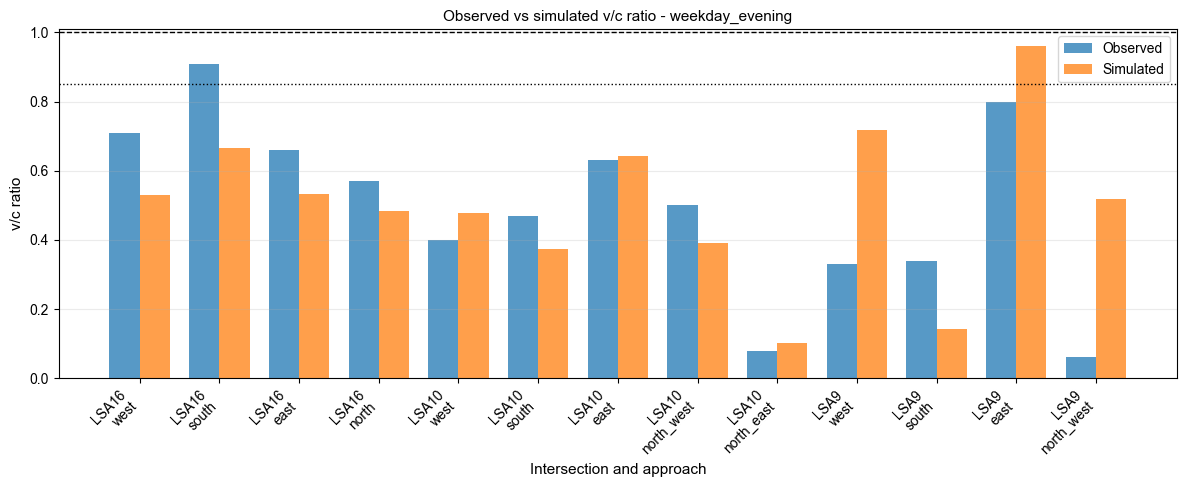

Saved: C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_comparison\figures\real_vs_sim\real_vs_sim_vc_weekday_evening.png


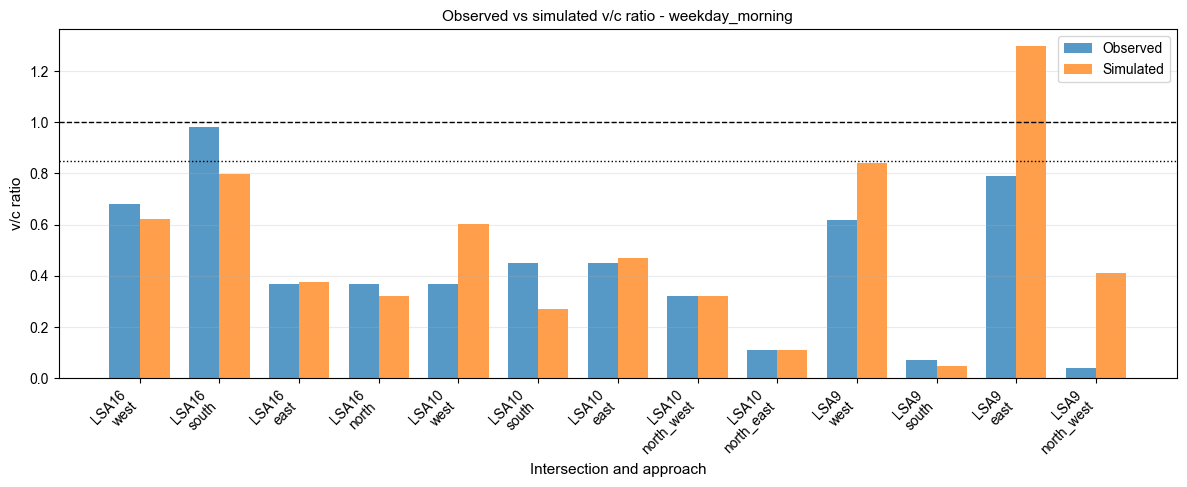

Saved: C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_comparison\figures\real_vs_sim\real_vs_sim_vc_weekday_morning.png


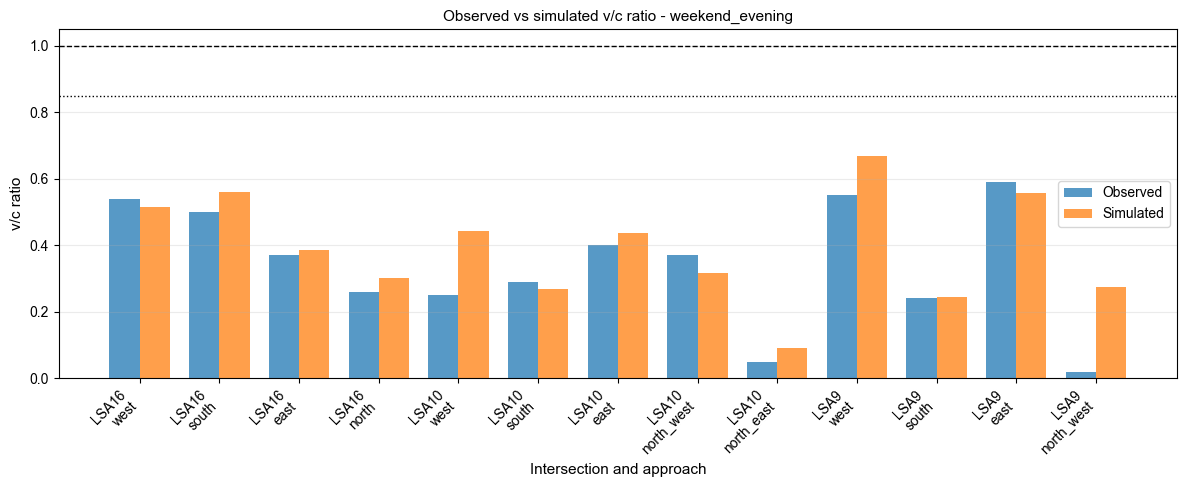

Saved: C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_comparison\figures\real_vs_sim\real_vs_sim_vc_weekend_evening.png


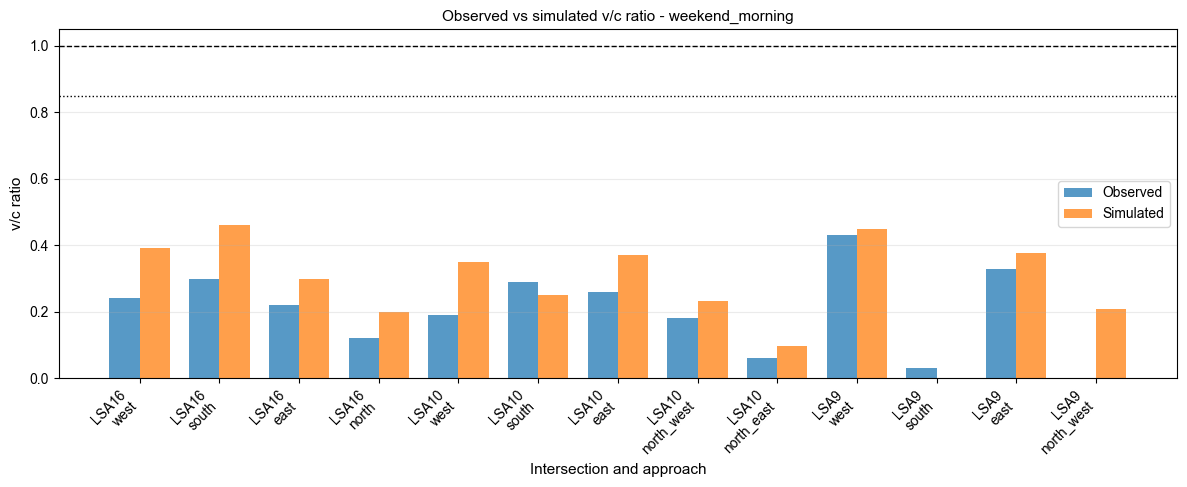

Saved: C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_comparison\figures\real_vs_sim\real_vs_sim_vc_weekend_morning.png


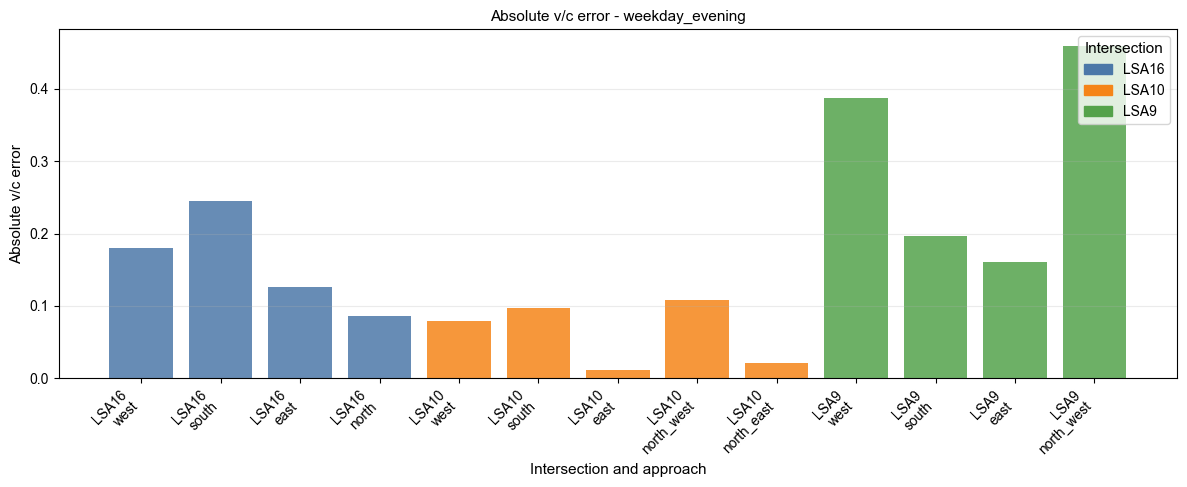

Saved: C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_comparison\figures\real_vs_sim\vc_absolute_error_weekday_evening.png


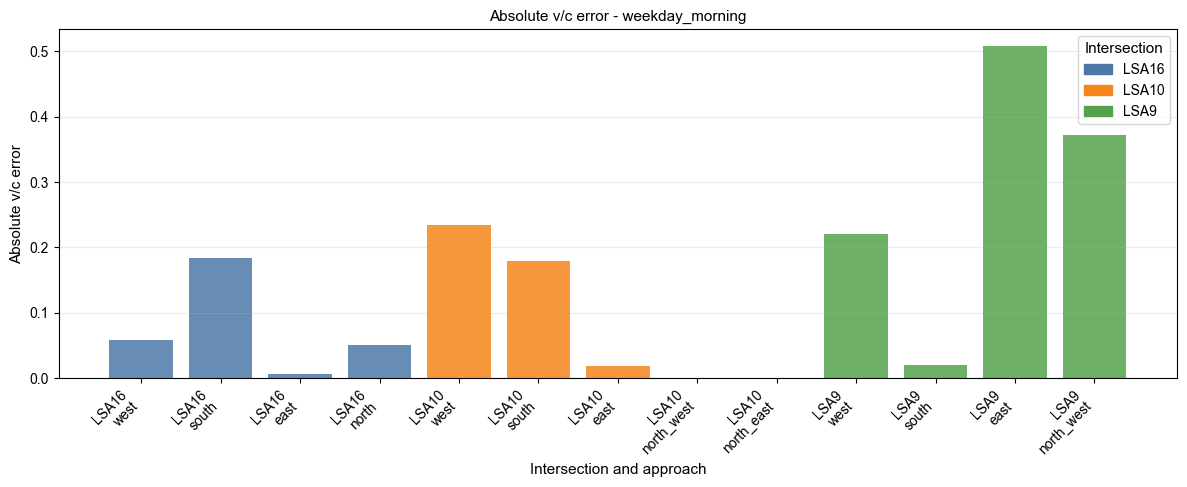

Saved: C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_comparison\figures\real_vs_sim\vc_absolute_error_weekday_morning.png


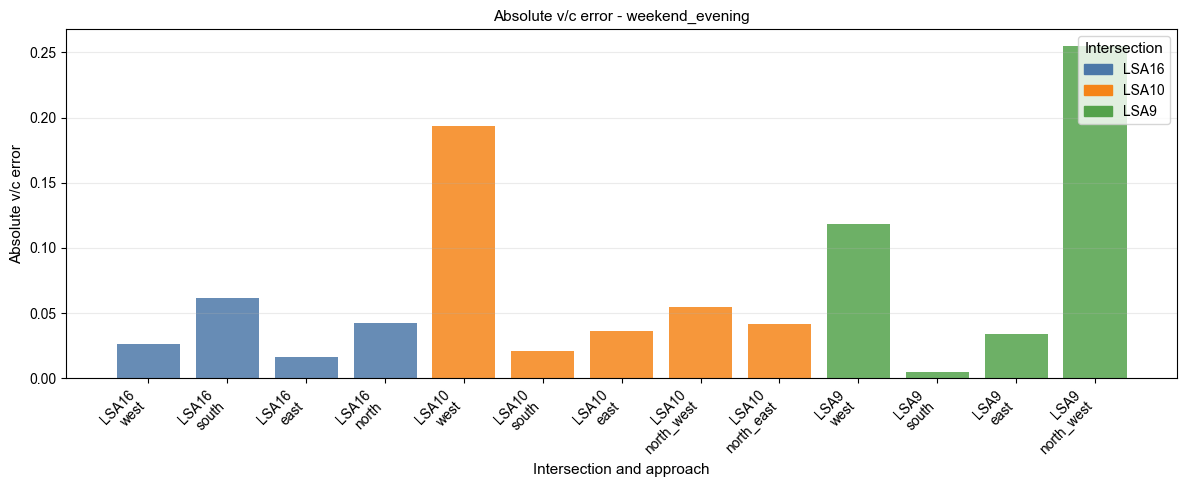

Saved: C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_comparison\figures\real_vs_sim\vc_absolute_error_weekend_evening.png


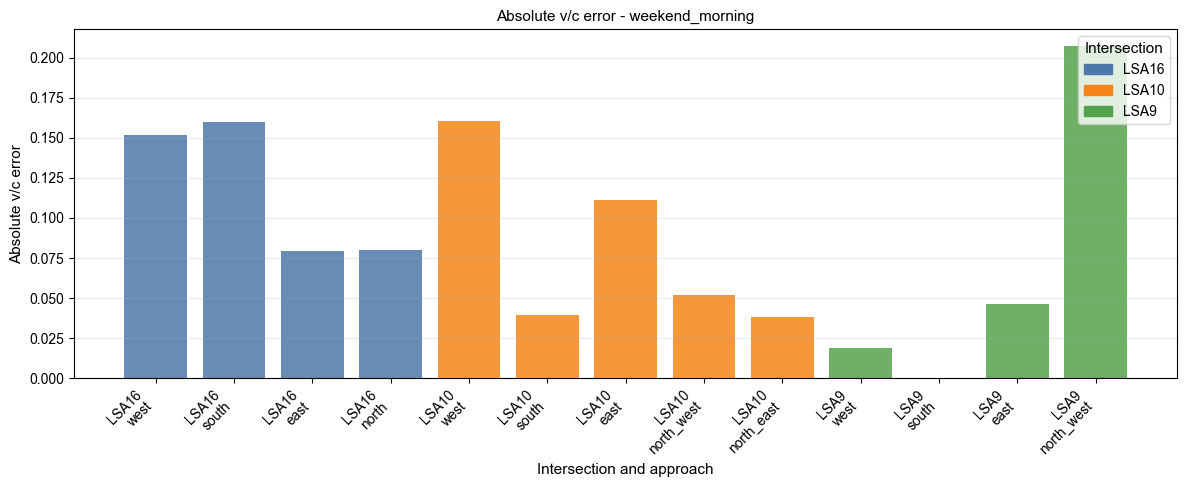

Saved: C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_comparison\figures\real_vs_sim\vc_absolute_error_weekend_morning.png


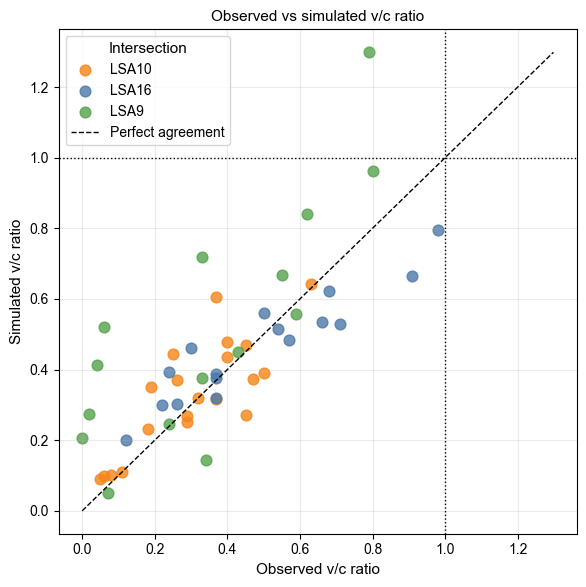

Saved: C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_comparison\figures\real_vs_sim\real_vs_sim_vc_scatter.png


In [22]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches

# ============================================================
# REAL vs SIMULATION COMPARISON FIGURES
# ============================================================

BASE = Path(
    r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_comparison\processed"
)

FIG_DIR = Path(
    r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_comparison\figures\real_vs_sim"
)
FIG_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(BASE / "real_vs_simulation_saturation_comparison.csv")

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 11,
    "axes.titlesize": 11,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})

lsa_order = {
    "LSA16": 1,
    "LSA10": 2,
    "LSA9": 3,
}

approach_order = {
    "west": 1,
    "south": 2,
    "east": 3,
    "north": 4,
    "north_west": 5,
    "north_east": 6,
}

lsa_colors = {
    "LSA16": "#4C78A8",
    "LSA10": "#F58518",
    "LSA9": "#54A24B",
}

# ============================================================
# 1) REAL vs SIM BAR CHART BY SCENARIO
# ============================================================

for scenario in df["scenario"].unique():

    temp = df[df["scenario"] == scenario].copy()

    temp["lsa_sort"] = temp["lsa"].map(lsa_order)
    temp["approach_sort"] = temp["approach"].map(approach_order)
    temp = temp.sort_values(["lsa_sort", "approach_sort"])

    temp["label"] = temp["lsa"] + "\n" + temp["approach"]

    x = np.arange(len(temp))
    width = 0.38

    plt.figure(figsize=(12, 5))

    plt.bar(
        x - width / 2,
        temp["real_v_c_ratio"],
        width,
        label="Observed",
        alpha=0.75,
    )

    plt.bar(
        x + width / 2,
        temp["sim_v_c_ratio"],
        width,
        label="Simulated",
        alpha=0.75,
    )

    plt.axhline(1.0, linestyle="--", linewidth=1, color="black")
    plt.axhline(0.85, linestyle=":", linewidth=1, color="black")

    plt.title(f"Observed vs simulated v/c ratio - {scenario}")
    plt.ylabel("v/c ratio")
    plt.xlabel("Intersection and approach")
    plt.xticks(x, temp["label"], rotation=45, ha="right")
    plt.grid(axis="y", alpha=0.25)
    plt.legend()

    plt.tight_layout()

    out_file = FIG_DIR / f"real_vs_sim_vc_{scenario}.png"
    plt.savefig(out_file, dpi=300)
    plt.show()

    print("Saved:", out_file)


# ============================================================
# 2) ABSOLUTE ERROR BAR CHART BY SCENARIO
# ============================================================

for scenario in df["scenario"].unique():

    temp = df[df["scenario"] == scenario].copy()

    temp["lsa_sort"] = temp["lsa"].map(lsa_order)
    temp["approach_sort"] = temp["approach"].map(approach_order)
    temp = temp.sort_values(["lsa_sort", "approach_sort"])

    temp["label"] = temp["lsa"] + "\n" + temp["approach"]
    colors = temp["lsa"].map(lsa_colors)

    plt.figure(figsize=(12, 5))

    plt.bar(
        temp["label"],
        temp["abs_error"],
        color=colors,
        alpha=0.85,
    )

    plt.title(f"Absolute v/c error - {scenario}")
    plt.ylabel("Absolute v/c error")
    plt.xlabel("Intersection and approach")
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis="y", alpha=0.25)

    legend_items = [
        mpatches.Patch(color=color, label=lsa)
        for lsa, color in lsa_colors.items()
    ]
    plt.legend(handles=legend_items, title="Intersection", loc="upper right")

    plt.tight_layout()

    out_file = FIG_DIR / f"vc_absolute_error_{scenario}.png"
    plt.savefig(out_file, dpi=300)
    plt.show()

    print("Saved:", out_file)


# ============================================================
# 3) REAL vs SIM SCATTER PLOT
# ============================================================

plt.figure(figsize=(6, 6))

for lsa, temp in df.groupby("lsa"):
    plt.scatter(
        temp["real_v_c_ratio"],
        temp["sim_v_c_ratio"],
        label=lsa,
        s=60,
        alpha=0.8,
        color=lsa_colors.get(lsa)
    )

max_val = max(
    df["real_v_c_ratio"].max(),
    df["sim_v_c_ratio"].max()
)

plt.plot(
    [0, max_val],
    [0, max_val],
    linestyle="--",
    color="black",
    linewidth=1,
    label="Perfect agreement"
)

plt.axhline(1.0, linestyle=":", color="black", linewidth=1)
plt.axvline(1.0, linestyle=":", color="black", linewidth=1)

plt.title("Observed vs simulated v/c ratio")
plt.xlabel("Observed v/c ratio")
plt.ylabel("Simulated v/c ratio")
plt.grid(alpha=0.25)
plt.legend(title="Intersection")

plt.tight_layout()

out_file = FIG_DIR / "real_vs_sim_vc_scatter.png"
plt.savefig(out_file, dpi=300)
plt.show()

print("Saved:", out_file)

**Evaluation** 
### Comparison of Observed and Simulated Saturation Levels

The comparison between observed and simulated volume-to-capacity (v/c) ratios reveals that the simulation model is able to capture the general traffic dynamics of the study corridor. Across all scenarios, the relative distribution of traffic demand is reproduced consistently, particularly with respect to identifying highly loaded approaches.

A clear agreement can be observed for several approaches, where simulated and observed v/c ratios are closely aligned. This indicates that the demand estimation and signal representation within the simulation are generally appropriate. However, deviations in magnitude are present, especially for specific intersections and approaches.

The largest discrepancies are observed at LSA9, where the simulation tends to overestimate saturation levels. This is particularly visible for the east approach, which shows consistently higher simulated v/c ratios compared to observed values. These deviations may be attributed to simplified signal control logic, assumptions in route generation, and the lack of detailed driver behavior modeling.

In contrast, LSA16 shows relatively good agreement between observed and simulated values, indicating that the model is able to represent traffic conditions more accurately at this intersection. LSA10 exhibits moderate deviations, with both overestimation and underestimation depending on the scenario and approach.

From a temporal perspective, weekday scenarios—especially the morning peak—show the highest saturation levels and the largest discrepancies. Weekend scenarios, on the other hand, exhibit lower traffic demand and improved agreement between observed and simulated values.

Overall, the results demonstrate that the simulation model is capable of identifying critical locations and reproducing relative traffic patterns. While exact numerical agreement is not achieved, the model provides a sufficiently accurate representation for scenario-based analysis within the digital twin framework.

### Error Analysis

To further evaluate the model performance, the absolute error between observed and simulated v/c ratios was analyzed at the approach level. The results indicate that the magnitude of the error varies significantly across intersections and scenarios.

The highest errors are observed at LSA9, particularly during weekday peak periods. This suggests that the simulation tends to overestimate congestion levels at this intersection. In contrast, LSA16 shows relatively lower error values, indicating a better representation of real-world conditions.

LSA10 exhibits moderate error levels, with variations depending on the specific approach. In some cases, the simulation slightly overestimates demand, while in others it underestimates it. These inconsistencies highlight the sensitivity of the model to demand distribution and signal timing assumptions.

Despite these deviations, the overall error levels remain within an acceptable range for microscopic traffic simulation studies. The model successfully captures the spatial distribution of congestion and provides reliable insights into network performance.

Therefore, the simulation can be considered suitable for identifying bottlenecks and supporting scenario-based traffic analysis, even though exact numerical matching with observed data is not fully achieved.

### Correlation Between Observed and Simulated Results

The relationship between observed and simulated v/c ratios is further illustrated using a scatter plot. The results show a clear positive correlation between the two datasets, indicating that the simulation captures the overall trend of traffic demand.

Most data points are distributed around the line of perfect agreement, although some deviations are present. In particular, several points lie above the reference line, confirming a tendency of the simulation to overestimate saturation in certain cases.

The spread of the points increases for higher v/c values, suggesting that model accuracy decreases under highly congested conditions. This is a common limitation in traffic simulation, where small differences in demand or signal timing can lead to larger variations in congestion levels.

Nevertheless, the observed correlation confirms that the simulation model is able to reproduce the general behavior of the traffic system and provides a meaningful approximation of real-world conditions.


### Conclusion and Future Work

The results of this study show that the developed SUMO-based digital twin can reproduce the general traffic behavior of the selected corridor and provide useful insights into approach-level traffic performance. By integrating detector-based demand data and signal timing information, the model was able to represent the main spatial and temporal traffic patterns within the study area.

The calibration and validation results indicate that the simulation does not match the observed data perfectly in every case. However, the model successfully identifies the most critical approaches and reflects the overall differences between weekday and weekend traffic conditions. In particular, higher saturation levels were observed during weekday peak periods, while weekend scenarios showed more stable and less congested conditions. This confirms that the simulation is suitable for evaluating traffic conditions at the corridor level and for identifying potential bottlenecks.

The comparison between observed and simulated saturation levels also shows that the model captures the relative distribution of congestion reasonably well. Some deviations remain, especially at specific approaches such as LSA9 east, where the simulation tends to overestimate saturation. These differences can be explained by simplified signal control logic, limitations in route generation, missing local driver behavior, and uncertainties in detector-based demand reconstruction.

Overall, the developed digital twin provides a functional basis for scenario-based traffic analysis. It can support the assessment of traffic performance indicators such as saturation, demand distribution, and approach-level capacity utilization. Although the current implementation is not yet a fully real-time operational digital twin, it represents an important step toward data-driven traffic simulation and short-term traffic management applications.

Future work should focus on improving the representation of real-world signal control. In this study, static signal programs were derived from observed signal state data and implemented in SUMO. However, real traffic signals are often actuated and respond dynamically to traffic demand. Therefore, a more detailed implementation of actuated or adaptive signal logic would likely improve the accuracy of the simulation.

Another important extension is the integration of additional performance indicators such as queue length, delay, travel time, number of stops, and emissions. These indicators would provide a more complete evaluation of traffic conditions and would allow a broader assessment of operational performance at both intersection and corridor level.

Furthermore, the demand generation process could be improved by including additional data sources, such as floating car data, turning movement counts, or origin-destination information. This would reduce uncertainty in route choice and improve the realism of simulated traffic flows.

Finally, future work should further develop the prediction component of the digital twin. The integration of short-term forecasting models, such as LSTM-based traffic prediction, can enable the digital twin to estimate upcoming traffic conditions and support proactive traffic management decisions. In this way, the system could evolve from an offline simulation-based analysis tool toward a more dynamic and decision-support-oriented digital twin.
